In [33]:
import os
import sys

import plotly.express as px
import plotly.graph_objects as go

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *
import statsmodels.api as sm



In [34]:
temp_feature = "temperature"
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')

In [35]:
df['is_good_peak'].drop_duplicates()

0         1
17        2
982       0
1445      6
1446      4
194451    3
387989    5
396830    7
Name: is_good_peak, dtype: int64

In [36]:
csv_read_path = os.path.join(project_root, "data", "interim", "factors.csv")
df_factors = pd.read_csv(csv_read_path)
df_factors["Date"] = pd.to_datetime(df_factors["Date"])

coefs = {}
grouped = df_factors.groupby(['PowerPlantCode', 'PowerPlantName', "UnitCode"])

for (pp_code, pp_name, unit_code), g in grouped:
    latest_row = g.sort_values("Date", ascending=False).iloc[0]
    
    coefs[(pp_name, unit_code)] = (latest_row["a1IndexGas"], latest_row["b1IndexGas"])

In [37]:
color_map = {
    1: "purple",
    2: "brown",
    3: "pink",
    4: "gray",
    5: "black",
    6: "red",
    7: "green",
    8: "blue",
    9: "orange"
}

In [38]:
def plot_with_lines(df, x_col, y_col, coefs, name, code, save_path=None):
    """رسم نمودار پراکندگی با خطوط رگرسیون و نقاط پیش‌بینی"""
    
    # نمودار اصلی scatter
    fig = go.Figure()

    for peak_value, color in color_map.items():
        df_subset = df[df["is_good_peak"] == peak_value]
        fig.add_trace(go.Scatter(
            x=df_subset[x_col],
            y=df_subset[y_col],
            mode="markers",
            marker=dict(size=4, color=color),
            name=f"is_good_peak = {peak_value}",
            hovertext=df_subset['datetime']
        ))
    # ظاهر نقاط
    fig.update_traces(
        marker=dict(size=4, sizemode='diameter', sizeref=1, opacity=0.7)
    )
    
    a, b = coefs.get((name, code))
    x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    y_line = a * x_line + b

    fig.add_trace(go.Scatter(
        x=x_line,
        y=y_line,
        mode="lines",
        name=f"y = {a:.3f}x + {b:.3f}",
        line=dict(dash="dash", width=2)
    ))
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.write_html(save_path)
    else:
        fig.show()


def show(df_m1, save=False, param=None):
    name, code = param['name'], param['code']
    
    fig = px.scatter(
        df_m1,
        x="datetime",
        y='generation',
        color='is_good_peak',
        title='Generation over Time by Batch Interval',
        labels={'generation': 'Generation', 'datetime': 'Time'},
        hover_data=['datetime', 'generation', temp_feature]
    )     

    if save:
        path = f"{project_root}/src/visualization/unit_figs/new_new_filter6/{name}-{code}_l.html"
        os.makedirs(os.path.dirname(path), exist_ok=True)
        fig.write_html(path)
    else:
        fig.show()

    # # نمودار ۲: generation vs temperature
    save_path = (f"{project_root}/src/visualization/unit_figs/new_new_filter6/{name}-{code}_s.html"
                 if save else None)
    plot_with_lines(
        df_m1, temp_feature, 'generation', coefs, name, code,
        save_path=save_path
    )
    

In [39]:
power_plants = df[['name', 'code']].drop_duplicates()

for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code
    ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=2))
    df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
    try:
        show(df_n_c_plot, save=True, param={"name": name_plot, "code": code_plot})
    except Exception as e:
        print(e)
        print(name_plot,code_plot,len(df_n_c_plot))

,id,name,code,date,hour,load_level,forecasted_load,required,declared,status,...,snow,surface_pressure,evapotranspiration,wind_speed,wind_direction,datetime,season,day_of_week,month,is_good_peak
894868,149,قم,G11,2021-06-01,1,M,50125,100.599,100.6,SO,...,0.0,893.74580,0.00,6.130579,220.23628,2021-06-01 01:00:00,summer,1,6,7
894869,149,قم,G11,2021-06-01,2,M,48325,102.096,102.1,SO,...,0.0,893.31213,0.00,7.594208,238.57048,2021-06-01 02:00:00,summer,1,6,7
894870,149,قم,G11,2021-06-01,3,L,47000,102.799,102.8,SO,...,0.0,893.30164,0.00,9.957109,257.47120,2021-06-01 03:00:00,summer,1,6,7
894871,149,قم,G11,2021-06-01,4,L,46042,103.499,103.5,SO,...,0.0,893.36910,0.00,10.895577,277.59454,2021-06-01 04:00:00,summer,1,6,7
894872,149,قم,G11,2021-06-01,5,L,45040,104.299,104.3,SO,...,0.0,893.53485,0.00,9.504273,294.62354,2021-06-01 05:00:00,summer,1,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
927669,149,قم,G11,2025-02-24,20,P,43125,331.877,114.0,SO,...,0.0,894.46606,0.05,25.364037,263.48030,2025-02-24 20:00:00,winter,0,2,5
927670,149,قم,G11,2025-02-24,21,P,42636,336.188,116.1,SO,...,0.0,895.27930,0.04,26.319422,266.86370,2025-02-24 21:00:00,winter,0,2,5
927671,149,قم,G11,2025-02-24,22,M,41713,339.236,116.8,SO,...,0.0,895.56760,0.03,17.414476,352.87506,2025-02-24 22:00:00,winter,0,2,5
927672,149,قم,G11,2025-02-24,23,M,41466,333.036,116.8,SO,...,0.0,896.49960,0.03,17.819090,351.87000,2025-02-24 23:00:00,winter,0,2,5


In [253]:

from sklearn.cluster import KMeans


def cluster_and_plot(x, y,a=-0.78 ,b=0):
    """
    x, y : 1D numpy arrays of same length
    """

    # ساخت داده 2 بعدی
    t = (a * x - y + b) / np.sqrt(a**2 + 1)
    
    # 2) خوشه‌بندی به دو دسته
    kmeans = KMeans(n_clusters=2, random_state=0)
    labels = kmeans.fit_predict(t.reshape(-1, 1))

    # 3) رسم
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, c=labels, s=1)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Unsupervised clustering (PCA + KMeans)")
    plt.show()

    return labels


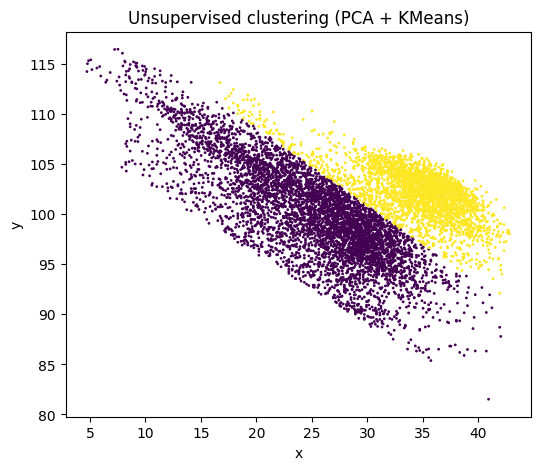

In [257]:
name_plot = "قم"
code_plot = "G12"
ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=2))
df_n_c = ds_n_c_plot.filter_name_code(name_plot, code_plot)
X = df_n_c[temp_feature].values
y = df_n_c["generation"].values
mask = (X>0)&((y - (X*(-0.7)+140))>-30)

labels = cluster_and_plot(X[mask], y[mask])

In [279]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks


def find_valley_on_projection(t,temp_c=-1):
    """
    Given 1D projection t, find the lowest density valley between two main peaks
    """
    kde = gaussian_kde(t)
    t_grid = np.linspace(t.min(), t.max(), 500)
    left_1 = np.searchsorted(t_grid, temp_c, side='right')

    density = kde(t_grid)
    peaks, _ = find_peaks(density)
    if len(peaks) < 2:
        return None, None

    # two highest peaks
    peaks = peaks[np.argsort(density[peaks])[-2:]]
    left, right = np.sort(peaks)
    left = max(left,left_1)
    valley_idx = left + np.argmin(density[left:right])
    return t_grid[valley_idx], density[valley_idx]


def find_best_gap_line(x, y, angle_range=(-np.pi/2*(45/90), -np.pi/2*(25/90)), n_angles=20):
    """
    Finds the line y = a*x + b passing through the lowest-density linear gap
    """

    best_score = np.inf
    best_params = None

    angles = np.linspace(angle_range[0], angle_range[1], n_angles)

    for theta in angles:
        # slope
        print(theta)
        a = np.tan(theta)

        # normal projection
        t = (a * x - y) / np.sqrt(a*a + 1)

        t0, density_min = find_valley_on_projection(t)
        if t0 is None:
            continue

        # lower density = better gap
        if density_min < best_score:
            best_score = density_min
            b = -t0 * np.sqrt(a*a + 1)
            best_params = (a, b)

    return best_params


def plot_result(x, y, a, b):
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, s=5, alpha=0.6)

    xx = np.linspace(x.min(), x.max(), 300)
    yy = a * xx + b
    plt.plot(xx, yy, 'r', linewidth=2)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Unsupervised Maximum Gap Line")
    plt.grid()
    plt.show()


-0.7853981633974483
-0.7670262765343501
-0.7486543896712519
-0.7302825028081537
-0.7119106159450554
-0.6935387290819572
-0.675166842218859
-0.6567949553557608
-0.6384230684926626
-0.6200511816295644
-0.6016792947664662
-0.583307407903368
-0.5649355210402698
-0.5465636341771716
-0.5281917473140734
-0.5098198604509752
-0.491447973587877
-0.4730760867247788
-0.4547041998616806
-0.4363323129985824


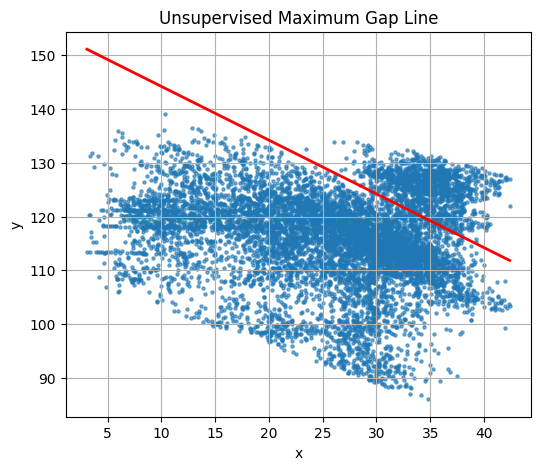

a = -1.000, b = 154.225


In [289]:
name_plot = "شهدای پاکدشت - دماوند"
code_plot = "G14"
ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=2))
df_n_c = ds_n_c_plot.filter_name_code(name_plot, code_plot)
X = df_n_c[temp_feature].values
y = df_n_c["generation"].values
mask = (X>0)&((y - (X*(-0.7)+140))>-30)

X = X[mask]
y = y[mask]

a, b = find_best_gap_line(X, y)
plot_result(X, y, a, b)

print(f"a = {a:.3f}, b = {b:.3f}")


In [271]:
name_plot = "قم"
code_plot = "G11"
ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=2))
df_n_c = ds_n_c_plot.filter_name_code(name_plot, code_plot)
import numpy as np

X = df_n_c[temp_feature].values
y = df_n_c["generation"].values
mask = (X>20)
y = y[mask]
X = X[mask]

C:\Users\S.H.Jasbi\AppData\Local\Temp\ipykernel_8512\74157028.py:3: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



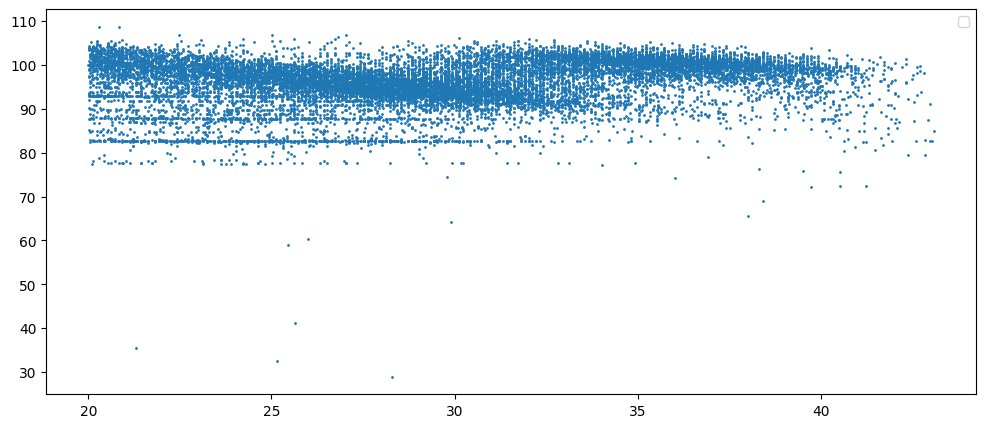

In [272]:
plt.figure(figsize=(12,5))
plt.scatter(X,y,s=1)
plt.legend()

In [240]:
    name = "شهدای پاکدشت - دماوند"
code = "G11"

df_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=2)).filter_name_code(name, code)

filtered20to25_df = df_n_c_plot[(df_n_c_plot[temp_feature] >= 20) & (df_n_c_plot[temp_feature] <= 25)]
filtered20to25_df = filtered20to25_df[filtered20to25_df["is_good_peak"] >= 6]

model = LinearRegression()
model.fit(filtered20to25_df[[temp_feature]], filtered20to25_df["generation"])    
 
t_c = 25
print(len(df_n_c_plot))
# داده‌های با دمای >= 25 برای خوشه‌بندی
df_kmeans = df_n_c_plot[df_n_c_plot[temp_feature] >= t_c]
y_pred = model.predict(df_kmeans[[temp_feature]])
df_kmeans = df_kmeans[df_kmeans["generation"] >= y_pred - 20]

# داده‌ها برای KMeans
X = df_kmeans[["generation", temp_feature]]

# اجرای KMeans
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_   # <-- مراکز خوشه‌ها

# اضافه کردن لیبل خوشه‌ها
df_kmeans = df_kmeans.copy()
df_kmeans["cluster"] = labels.astype(str)

# داده‌های دمای کمتر از 25
df_low = df_n_c_plot[df_n_c_plot[temp_feature] < t_c].copy()
df_low["cluster"] = "below_25"

# ترکیب داده‌ها برای رسم
df_plot = pd.concat([df_kmeans, df_low], ignore_index=True)

# --- رسم نمودار اصلی ---
fig = px.scatter(
    df_plot,
    x=temp_feature,
    y="generation",
    color="cluster",
    title="KMeans Clustering (with below 25 & centroids)",
)

fig.update_traces(
    marker=dict(size=2, opacity=0.7)
)

y_pred = model.predict(np.arange(0,50).reshape(-1,1))
fig.add_trace(go.Scatter(
    x=np.arange(0,50),
    y=y_pred,
    mode="lines",
    name=f"prediction",
    line=dict(dash="solid", width=2)
))
    
# --- رسم مراکز خوشه‌ها ---
fig.add_trace(
    go.Scatter(
        x=centers[:, 1],         # temp_feature
        y=centers[:, 0],         # generation
        mode="markers+text",
        marker=dict(
            size=14,
            symbol="x",
            line=dict(width=2),
        ),
        text=["C0", "C1"],        # نام‌گذاری مراکز
        textposition="top center",
        name="centroids"
    )
)

# ذخیره خروجی
_ = fig.write_html(
    f"{project_root}/src/visualization/unit_figs/kmeans/{name}-{code}_s.html"
)


IndentationError: unexpected indent (3163209992.py, line 1)

In [195]:
name = "قم"
code = "G11"

df_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=5)).filter_name_code(name, code)

filtered20to25_df = df_n_c_plot[(df_n_c_plot[temp_feature] >= 10) & (df_n_c_plot[temp_feature] <= 25)]
filtered20to25_df = filtered20to25_df[filtered20to25_df["is_good_peak"] >= 6]
model = LinearRegression()
model.fit(filtered20to25_df[[temp_feature]], filtered20to25_df["generation"])    
 
t_c = 25
# داده‌های با دمای >= 25 برای خوشه‌بندی
df_kmeans = df_n_c_plot[df_n_c_plot[temp_feature] >= t_c]
y_pred = model.predict(df_kmeans[[temp_feature]])
df_kmeans = df_kmeans[df_kmeans["generation"] >= y_pred + 5]

replace_dict = {5:7,6:8}
df.loc[df_kmeans.index, "is_good_peak"] = df.loc[df_kmeans.index, "is_good_peak"].map(replace_dict).fillna(df["is_good_peak"])

filter6(initial_label=5,max_label=6)


26993


U:\ML_project\Bargh_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [32]:
power_plants = df[['name', 'code']].drop_duplicates()

lens = []
names = []
for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code
    ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=7))
    df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
    
    if len(df_n_c_plot) == 0:
        continue
        
    x = df_n_c_plot[[temp_feature]]
    y = df_n_c_plot["generation"]
    model = LinearRegression()
    model.fit(x,y)
    
    lens.append(len(x))
    names.append([name_plot, code_plot,lens[-1]])
    

In [33]:
lens = np.array(lens)
names = np.array(names)

In [34]:
names

array([['جنوب اصفهان - چهلستون', 'G11', '6'],
       ['جنوب اصفهان - چهلستون', 'G12', '4'],
       ['جنوب اصفهان - چهلستون', 'G13', '2'],
       ['جنوب اصفهان - چهلستون', 'G14', '2'],
       ['جنوب اصفهان - چهلستون', 'G15', '25'],
       ['جنوب اصفهان - چهلستون', 'G16', '8'],
       ['حافظ', 'G11', '359'],
       ['حافظ', 'G12', '208'],
       ['حافظ', 'G13', '590'],
       ['حافظ', 'G14', '837'],
       ['حافظ', 'G15', '263'],
       ['حافظ', 'G16', '174'],
       ['سبلان', 'G11', '11'],
       ['سبلان', 'G12', '4'],
       ['سبلان', 'G13', '2'],
       ['سبلان', 'G15', '12'],
       ['سبلان', 'G16', '41'],
       ['سیکل ترکیبی ارومیه', 'G11', '11'],
       ['سیکل ترکیبی ارومیه', 'G12', '15'],
       ['سیکل ترکیبی ارومیه', 'G13', '8'],
       ['سیکل ترکیبی ارومیه', 'G14', '12'],
       ['سیکل ترکیبی ارومیه', 'G15', '18'],
       ['سیکل ترکیبی ارومیه', 'G16', '13'],
       ['سیکل ترکیبی شیروان', 'G11', '971'],
       ['سیکل ترکیبی شیروان', 'G12', '49'],
       ['سیکل ترکیبی شیروان', 'G

In [38]:
names[lens > 300]

array([['حافظ', 'G11', '359'],
       ['حافظ', 'G13', '590'],
       ['حافظ', 'G14', '837'],
       ['سیکل ترکیبی شیروان', 'G11', '971'],
       ['سیکل ترکیبی شیروان', 'G13', '309'],
       ['سیکل ترکیبی شیروان', 'G14', '482'],
       ['سیکل ترکیبی یزد', 'G14', '760'],
       ['سیکل ترکیبی یزد', 'G16', '1727'],
       ['شهدای پاکدشت - دماوند', 'G11', '4133'],
       ['شهدای پاکدشت - دماوند', 'G12', '1660'],
       ['شهدای پاکدشت - دماوند', 'G13', '711'],
       ['شهدای پاکدشت - دماوند', 'G14', '1184'],
       ['شهدای پاکدشت - دماوند', 'G15', '1521'],
       ['شهدای پاکدشت - دماوند', 'G16', '907'],
       ['شهدای پاکدشت - دماوند', 'G17', '1596'],
       ['شهدای پاکدشت - دماوند', 'G18', '1454'],
       ['شهدای پاکدشت - دماوند', 'G19', '1461'],
       ['شهدای پاکدشت - دماوند', 'G20', '1960'],
       ['قم', 'G11', '5432'],
       ['قم', 'G12', '1745'],
       ['قم', 'G13', '2534']], dtype='<U21')

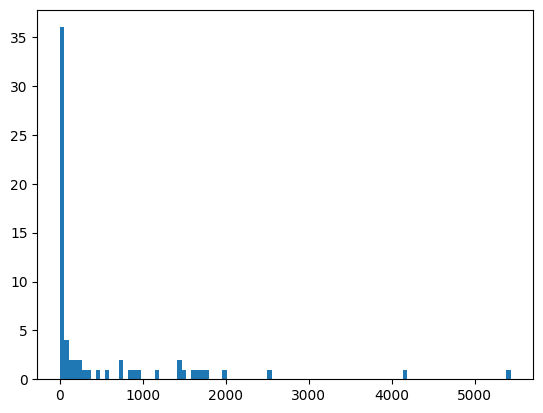

In [36]:
a = plt.hist(lens,bins=100)

In [19]:
a, b, c = len(a)

TypeError: cannot unpack non-iterable int object

In [55]:
df[['name', 'code']].drop_duplicates()

,name,code
0,جنوب اصفهان - چهلستون,G11
34483,جنوب اصفهان - چهلستون,G12
46887,جنوب اصفهان - چهلستون,G13
59291,جنوب اصفهان - چهلستون,G14
71695,جنوب اصفهان - چهلستون,G15
...,...,...
1095872,گیلان,G12
1108276,گیلان,G13
1120680,گیلان,G14
1133084,گیلان,G15
